In [ ]:
from google.colab import files
files.upload()

In [3]:
!unzip -q assignment22.zip -d /content/assignment22
%cd /content/assignment22
!ls

/content/assignment22
data.py       model.py	 sample.py     smoke_test.py
diffusion.py  README.md  scheduler.py  train.py


In [4]:
import torch
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Tesla T4


In [5]:
!python smoke_test.py

[conditional=False, schedule=linear] loss=1.1783  OK
[conditional=False] DDPM sample shape (4, 1, 32, 32)  OK
[conditional=False] DDIM sample shape (4, 1, 32, 32)  OK
[conditional=True, schedule=linear] loss=1.0480  OK
[conditional=True] DDPM sample shape (4, 1, 32, 32)  OK
[conditional=True] DDIM sample shape (4, 1, 32, 32)  OK
[conditional=False, schedule=cosine] loss=1.1315  OK
[conditional=False] DDPM sample shape (4, 1, 32, 32)  OK
[conditional=False] DDIM sample shape (4, 1, 32, 32)  OK
[conditional=True, schedule=cosine] loss=1.1588  OK
[conditional=True] DDPM sample shape (4, 1, 32, 32)  OK
[conditional=True] DDIM sample shape (4, 1, 32, 32)  OK

All smoke tests passed.


In [6]:
!python train.py \
  --epochs 20 \
  --batch_size 128 \
  --schedule cosine \
  --conditional \
  --p_uncond 0.1 \
  --sample_every 5

Using device: cuda
100% 9.91M/9.91M [00:01<00:00, 4.98MB/s]
100% 28.9k/28.9k [00:00<00:00, 129kB/s]
100% 1.65M/1.65M [00:01<00:00, 1.20MB/s]
100% 4.54k/4.54k [00:00<00:00, 15.1MB/s]
Model params: 6.12M
Conditional: True | schedule: cosine | T: 1000
epoch 0 step 100 loss 0.0837
epoch 0 step 200 loss 0.0536
epoch 0 step 300 loss 0.0497
epoch 0 step 400 loss 0.0522
== epoch 0 done | avg loss 0.0883 ==
epoch 1 step 500 loss 0.0435
epoch 1 step 600 loss 0.0372
epoch 1 step 700 loss 0.0432
epoch 1 step 800 loss 0.0400
epoch 1 step 900 loss 0.0368
== epoch 1 done | avg loss 0.0396 ==
epoch 2 step 1000 loss 0.0368
epoch 2 step 1100 loss 0.0398
epoch 2 step 1200 loss 0.0357
epoch 2 step 1300 loss 0.0302
epoch 2 step 1400 loss 0.0358
== epoch 2 done | avg loss 0.0352 ==
epoch 3 step 1500 loss 0.0365
epoch 3 step 1600 loss 0.0355
epoch 3 step 1700 loss 0.0365
epoch 3 step 1800 loss 0.0283
== epoch 3 done | avg loss 0.0333 ==
epoch 4 step 1900 loss 0.0339
epoch 4 step 2000 loss 0.0293
epoch 4 step

In [8]:
!python sample.py \
  --ckpt checkpoints/ddpm_last.pt \
  --conditional \
  --schedule cosine \
  --n_per_class 8 \
  --guidance_scale 3.0 \
  --sampler ddim \
  --ddim_steps 50 \
  --out samples/class_conditional_grid.png

Saved 80 samples to samples/class_conditional_grid.png
Each row = 1 digit class (0-9 top to bottom), 8 samples per row, guidance_scale=3.0


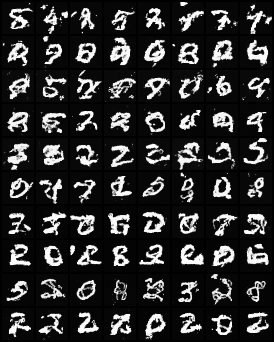

In [9]:
from IPython.display import Image, display
display(Image("samples/class_conditional_grid.png"))

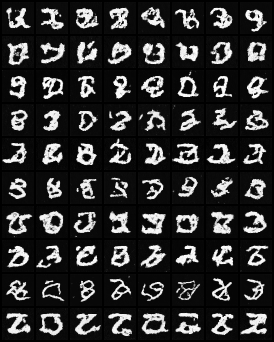

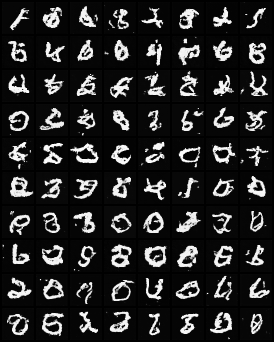

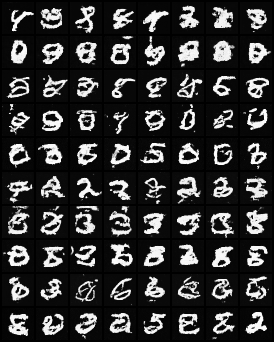

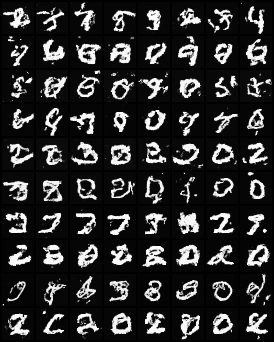

In [10]:
from IPython.display import display, Image
display(Image("samples/epoch_004.png"))
display(Image("samples/epoch_009.png"))
display(Image("samples/epoch_014.png"))
display(Image("samples/epoch_019.png"))